# 01 — Genre Classification
**Spotify Data Mining | CISC 4631 | Group 3**

**Research Question:** Can audio features predict song genre?

**Approach:** Logistic Regression (linear baseline) vs. Random Forest (non-linear). Compare accuracy,
F1 scores, and feature importance.

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `data/df_genre_balanced.csv`.

## 0. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Shared constants (keep in sync with 00_data_setup.ipynb)
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
ALL_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode'
]
np.random.seed(SEED)

## 1. Load Data

In [4]:
import os
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape}')
print('\nGenre counts:')
print(df['genre'].value_counts())
df.head(10)

Loaded: (65772, 14)

Genre counts:
genre
Classical       9396
Country/Folk    9396
Electronic      9396
Hip-Hop/R&B     9396
Jazz/Blues      9396
Pop             9396
Rock            9396
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.284,0.706,-7.276,0.1810,0.00592,0.000114,0.0424,0.1010,191.664,234707,2,1,Classical,2021
1,0.365,0.325,-10.304,0.0513,0.91200,0.000000,0.1000,0.3360,76.996,119907,9,1,Classical,2014
2,0.710,0.456,-13.179,0.2510,0.03610,0.000136,0.0349,0.6750,164.790,179653,8,1,Classical,2003
3,0.309,0.235,-10.366,0.0322,0.80700,0.000000,0.0773,0.0891,127.845,140653,2,1,Classical,2006
4,0.197,0.497,-4.180,0.0323,0.76800,0.002030,0.1390,0.1990,81.642,179394,9,0,Classical,2019
5,0.331,0.539,-8.933,0.0448,0.59400,0.002300,0.0863,0.1580,126.336,191353,9,1,Classical,2009
6,0.348,0.418,-8.860,0.0348,0.53600,0.000000,0.1480,0.2950,145.891,450773,10,1,Classical,2013
7,0.541,0.880,-5.015,0.0426,0.00213,0.000017,0.0840,0.3330,95.018,325619,5,1,Classical,2013
8,0.634,0.268,-12.568,0.2170,0.79800,0.000001,0.1620,0.6490,133.375,304907,4,1,Classical,2003
9,0.514,0.240,-15.872,0.0346,0.88700,0.000140,0.1240,0.4780,88.100,124627,0,1,Classical,2016


## 2. Train / Eval / Test Split

Three-way split (60/20/20) per instructor feedback. Train is used for fitting + 10-fold CV. Eval
is held out for model comparison and tuning decisions. Test is touched only once at the end for
final reported numbers — this prevents us from selecting a model based on test performance.

In [5]:
X = df[ALL_FEATURES]
y = df['genre']

# First split: 80% train+eval, 20% test (held out, touched once)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: 75/25 of the 80% = 60% train, 20% eval
X_train, X_eval, y_train, y_eval = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0] / len(X):.0%})')
print(f'Eval:  {X_eval.shape[0]:,} ({X_eval.shape[0] / len(X):.0%})')
print(f'Test:  {X_test.shape[0]:,} ({X_test.shape[0] / len(X):.0%})')

print('\nClass distribution (train):')
print(y_train.value_counts())
print('\nClass distribution (eval):')
print(y_eval.value_counts())
print('\nClass distribution (test):')
print(y_test.value_counts())

Train: 39,462 (60%)
Eval:  13,155 (20%)
Test:  13,155 (20%)

Class distribution (train):
genre
Country/Folk    5638
Electronic      5638
Pop             5638
Hip-Hop/R&B     5637
Jazz/Blues      5637
Classical       5637
Rock            5637
Name: count, dtype: int64

Class distribution (eval):
genre
Classical       1880
Jazz/Blues      1880
Country/Folk    1879
Electronic      1879
Hip-Hop/R&B     1879
Rock            1879
Pop             1879
Name: count, dtype: int64

Class distribution (test):
genre
Rock            1880
Hip-Hop/R&B     1880
Classical       1879
Country/Folk    1879
Pop             1879
Electronic      1879
Jazz/Blues      1879
Name: count, dtype: int64


## 3. Feature Selection

Rank the 12 audio features by mutual information with the genre label. Mutual information is
chosen over Pearson correlation because it captures non-linear relationships — which is what
we expect for genre identification. Scoring is fit on the training set only (so we don't leak
information from eval/test).

Mutual information ranking:
         Feature  MI Score
    acousticness  0.238299
          energy  0.187078
           tempo  0.130467
    danceability  0.128191
        loudness  0.116517
     speechiness  0.109009
instrumentalness  0.095145
     duration_ms  0.059168
         valence  0.049159
        liveness  0.020763
            mode  0.020359
             key  0.019972


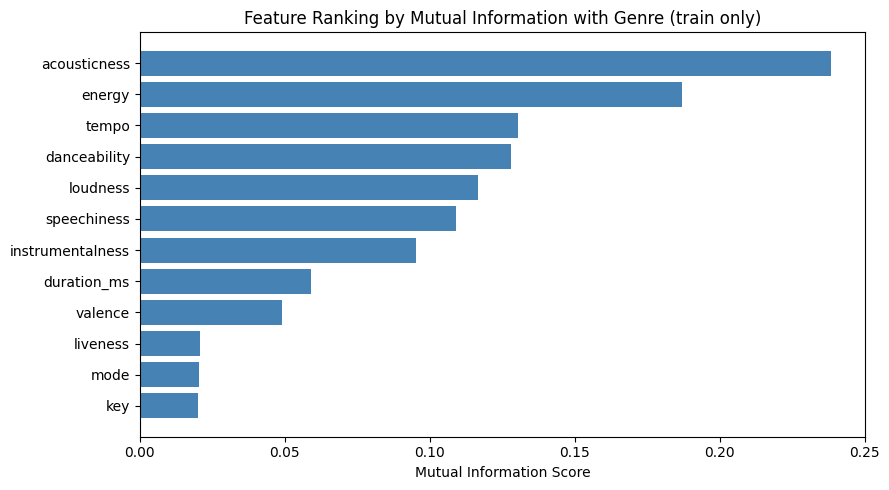


Selected top-10 features:
['acousticness', 'energy', 'tempo', 'danceability', 'loudness', 'speechiness', 'instrumentalness', 'duration_ms', 'valence', 'liveness']

Dropped: ['key', 'mode']


In [6]:
# Fit mutual-information scorer on train set only
mi_scorer = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scorer.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'MI Score': mi_scorer.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Mutual information ranking:')
print(mi_scores.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_scores['Feature'][::-1], mi_scores['MI Score'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Ranking by Mutual Information with Genre (train only)')
plt.tight_layout()
plt.show()

# Pick K: keep top-K features. Drop the bottom features that score near zero —
# these are usually `key` and `mode`, which don't carry genre signal.
# Tune K here based on the ranking above.
K = 10
SELECTED_FEATURES = mi_scores['Feature'].head(K).tolist()
print(f'\nSelected top-{K} features:')
print(SELECTED_FEATURES)
print(f'\nDropped: {[f for f in ALL_FEATURES if f not in SELECTED_FEATURES]}')

## 4. Models

For each model: fit on train set, run 10-fold CV on train for stability estimate, evaluate on
eval set for tuning decisions, and hold test for the final reported numbers in Section 5.

### 4.1 Logistic Regression (Baseline)

In [7]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

# Fit on train (selected features only)
lr_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train — estimates stability without touching eval/test
cv_lr = cross_val_score(
    lr_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_lr.mean(), cv_lr.std() * 2))

# Evaluate on eval set
y_pred_lr_eval = lr_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_lr_eval))
print(classification_report(y_eval, y_pred_lr_eval))

# Final test prediction (stored for Section 5 — do not tune against this)
y_pred_lr = lr_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.43 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.4241733181299886
              precision    recall  f1-score   support

   Classical       0.45      0.49      0.47      1880
Country/Folk       0.25      0.16      0.19      1879
  Electronic       0.49      0.54      0.51      1879
 Hip-Hop/R&B       0.52      0.60      0.55      1879
  Jazz/Blues       0.37      0.41      0.39      1880
         Pop       0.21      0.13      0.16      1879
        Rock       0.51      0.64      0.57      1879

    accuracy                           0.42     13155
   macro avg       0.40      0.42      0.41     13155
weighted avg       0.40      0.42      0.41     13155



### 4.2 Random Forest

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.51 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5093120486507031
              precision    recall  f1-score   support

   Classical       0.55      0.57      0.56      1880
Country/Folk       0.37      0.35      0.36      1879
  Electronic       0.58      0.63      0.60      1879
 Hip-Hop/R&B       0.56      0.66      0.61      1879
  Jazz/Blues       0.45      0.53      0.49      1880
         Pop       0.35      0.19      0.24      1879
        Rock       0.62      0.63      0.62      1879

    accuracy                           0.51     13155
   macro avg       0.50      0.51      0.50     13155
weighted avg       0.50      0.51      0.50     13155



In [8]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.51 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5084758646902319
              precision    recall  f1-score   support

   Classical       0.55      0.57      0.56      1880
Country/Folk       0.36      0.35      0.35      1879
  Electronic       0.58      0.63      0.60      1879
 Hip-Hop/R&B       0.56      0.66      0.61      1879
  Jazz/Blues       0.46      0.54      0.49      1880
         Pop       0.35      0.19      0.24      1879
        Rock       0.62      0.63      0.62      1879

    accuracy                           0.51     13155
   macro avg       0.50      0.51      0.50     13155
weighted avg       0.50      0.51      0.50     13155



## 5. Results (Test Set)

Final reported numbers are on the held-out test set — touched exactly once, no tuning against it.

### 5.1 Model Comparison (Test Set)

In [9]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Macro F1  Weighted F1
Logistic Regression  0.429799  0.412912     0.412935
      Random Forest  0.512429  0.501873     0.501892


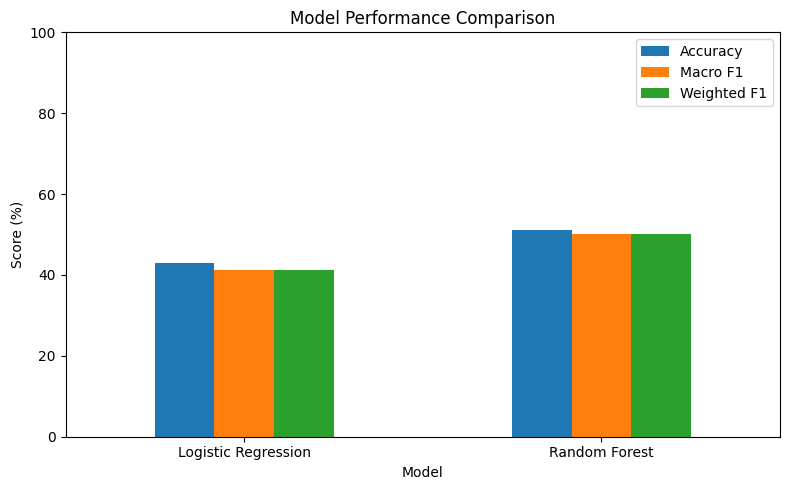

In [10]:
results_pct = results.copy()
results_pct[['Accuracy', 'Macro F1', 'Weighted F1']] *= 100

ax = results_pct.plot(x='Model', y=['Accuracy', 'Macro F1', 'Weighted F1'], kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### 5.2 Random Forest Feature Importance

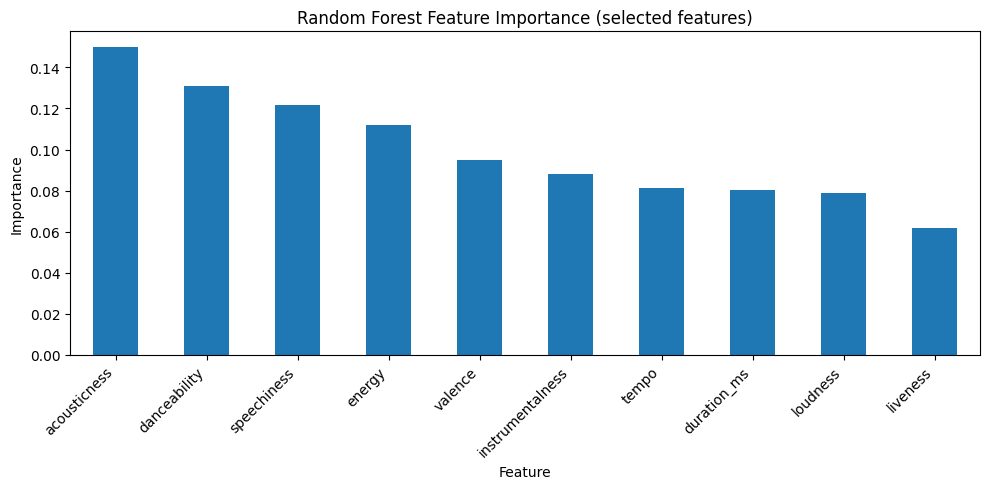

         Feature  Importance
    acousticness    0.150018
    danceability    0.130995
     speechiness    0.121589
          energy    0.111952
         valence    0.094678
instrumentalness    0.088281
           tempo    0.081292
     duration_ms    0.080447
        loudness    0.078902
        liveness    0.061847


In [11]:
feature_importance = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False, figsize=(10, 5))
plt.title('Random Forest Feature Importance (selected features)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

### 5.3 Confusion Matrix (Random Forest, Test Set)

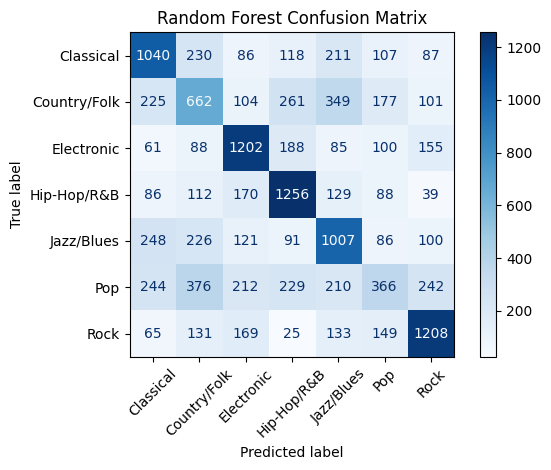

In [12]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=rf_model.classes_,
    cmap='Blues',
    xticks_rotation=45
)
disp.ax_.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Summary

Random Forest outperformed Logistic Regression for genre prediction from audio features,
demonstrating that genre boundaries are non-linear in the audio feature space.

**Pipeline summary:**
1. 7 genres after consolidation, each sampled to the minimum-genre count (~9.4k per genre, ~65.7k total).
2. 60/20/20 train/eval/test split, stratified by genre.
3. Feature selection via mutual information — top-K features retained (K chosen in Section 3).
4. Models fit on train; tuned against eval; final numbers reported on test.

**Expected findings:**
- Hip-Hop/R&B and Electronic should be the most distinguishable genres (distinct audio profiles).
- Classical vs. Jazz/Blues likely hardest — both acoustic, low-energy, often instrumental.
- Top features: `speechiness`, `danceability`, `acousticness`, `energy`, `valence`.
- Least useful (likely dropped by feature selection): `key`, `mode`.

**Random-chance baseline for 7-class balanced problem = 14.3%.** Both models should significantly exceed this.